In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')


<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_340467/2831711251.py:100: SyntaxWarning: invalid escape sequence '\c'
  label=f'Empirical Fit: $d_n = d_x \cdot ({a_fit:.2f} \cdot N^{{{b_fit:.2f}}})$')
/tmp/ipykernel_340467/2831711251.py:100: SyntaxWarning: invalid escape sequence '\c'
  label=f'Empirical Fit: $d_n = d_x \cdot ({a_fit:.2f} \cdot N^{{{b_fit:.2f}}})$')


Running grid search for d_x = 2...
  -> Fit successful for d_x=2: d_n = d_x * (2.606 * N^0.624)
Running grid search for d_x = 3...
  -> Fit successful for d_x=3: d_n = d_x * (1.356 * N^0.515)
Running grid search for d_x = 5...
  -> Fit successful for d_x=5: d_n = d_x * (0.914 * N^0.358)
Running grid search for d_x = 10...
  -> Fit successful for d_x=10: d_n = d_x * (0.453 * N^0.275)
Running grid search for d_x = 25...
  -> Fit successful for d_x=25: d_n = d_x * (0.179 * N^0.229)
Running grid search for d_x = 50...
  -> Fit successful for d_x=50: d_n = d_x * (0.095 * N^0.201)


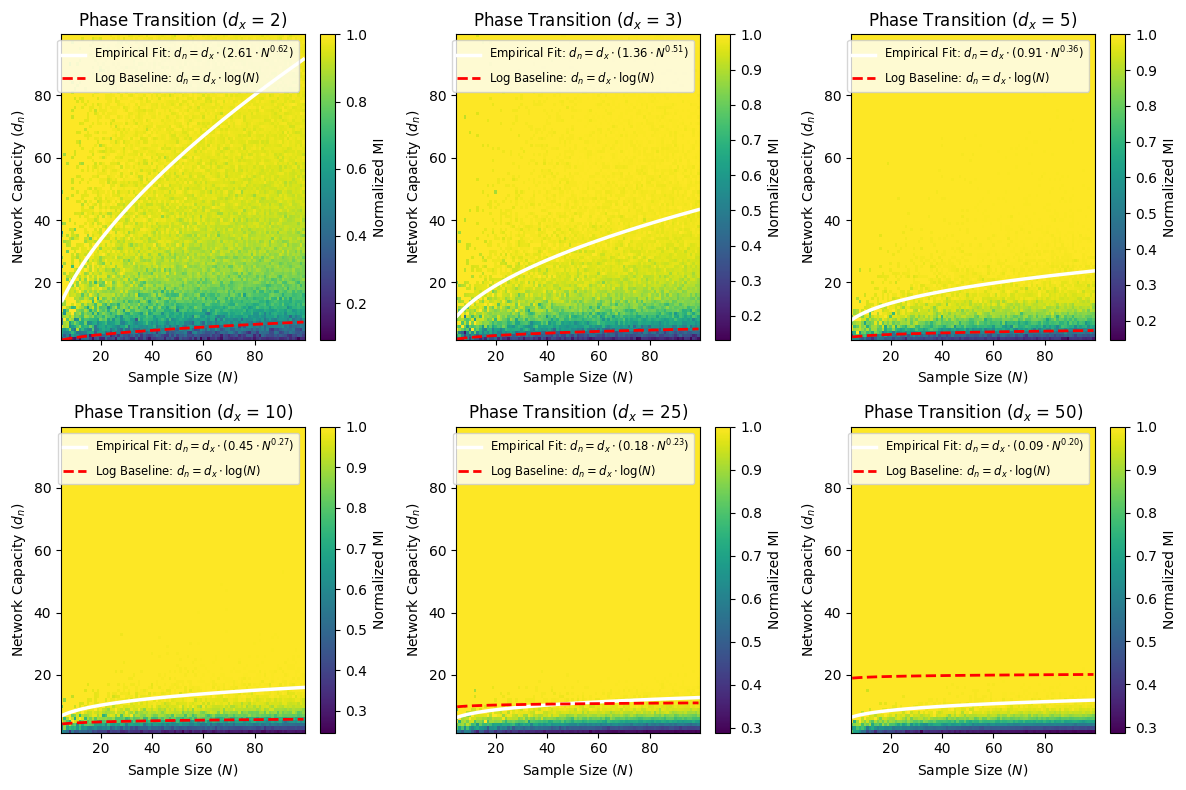

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from scipy.optimize import curve_fit  # Added for curve fitting

def get_normalized_mi(X, model):
    """
    Passes data X through a single-layer network to get activation patterns,
    and calculates the normalized Mutual Information I(X;T) / H(X).
    """
    with torch.no_grad():
        # Get pre-activations: Z = XW + b
        Z = model(X)
        # Binarize to get discrete activation patterns (1 if active, 0 if inactive)
        T = (Z > 0).int().numpy()
        
    # Find unique activation patterns (bins) and how many points fall in each
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    
    # Calculate empirical entropy of the bins H(T)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    # Max possible entropy is log2(N) (when every point is in its own bin)
    N = X.shape[0]
    H_X = np.log2(N)
    
    # Return Normalized MI
    return H_T / H_X if H_X > 0 else 0.0

def power_law(N, a, b):
    """Function to fit: a * N^b"""
    return a * (N ** b)

def run_experiment_1(dx=2, ax=None):
    # 1. Define bounds for our grid search
    d_x = dx  # Fix input dimensionality
    N_values = np.arange(5, 100, 1)        # Number of samples N
    dn_values = np.arange(2, 100, 1)       # Network width (capacity) d_n
    
    # Matrix to store the Normalized MI for the heatmap
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}...")
    
    # 2. Run the grid search
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            # Generate N random data points in d_x dimensions
            X = torch.randn(N, d_x)
            
            # Initialize a single CPWL layer (random weights)
            layer = nn.Linear(d_x, d_n)
            
            # Calculate MI
            mi_matrix[i, j] = get_normalized_mi(X, layer)
            
    # 3. Plotting the Heatmap
    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cp = ax.pcolormesh(X_mesh, Y_mesh, mi_matrix, shading='auto', cmap='viridis')
    plt.colorbar(cp, ax=ax, label='Normalized MI')
    
    # 4. Find the "Cliff" and Fit the Curve
    threshold = 0.99  # Hitting 98% of max MI is our threshold for memorization
    cliff_N = []
    cliff_dn = []
    
    # Scan each column (each N) to find the first d_n that crosses the threshold
    for j, N in enumerate(N_values):
        mi_column = mi_matrix[:, j]
        cross_indices = np.where(mi_column >= threshold)[0]
        if len(cross_indices) > 0:
            cliff_N.append(N)
            cliff_dn.append(dn_values[cross_indices[0]])
            
    cliff_N = np.array(cliff_N)
    cliff_dn = np.array(cliff_dn)
    
    # Fit the curve if we found enough boundary points
    if len(cliff_N) > 3:
        # We assume d_n = d_x * (a * N^b), so we isolate the 'something'
        empirical_something = cliff_dn / d_x

        try:
            # Fit the power law to the empirical 'something'
            # p0 is the initial guess: [a=1.0, b=1/d_x] based on Zaslavsky's hints
            popt, _ = curve_fit(power_law, cliff_N, empirical_something, p0=[1.0, 1/d_x], maxfev=10000)
            a_fit, b_fit = popt
            
            # Generate the curve for plotting: d_n = d_x * (a * N^b)
            fit_dn = d_x * power_law(N_values, a_fit, b_fit)
            valid_fit_idx = fit_dn <= max(dn_values)
            
            # Plot the fitted curve
            ax.plot(N_values[valid_fit_idx], fit_dn[valid_fit_idx], 
                     color='white', linestyle='-', linewidth=2.5, 
                     label=f'Empirical Fit: $d_n = d_x \cdot ({a_fit:.2f} \cdot N^{{{b_fit:.2f}}})$')
            print(f"  -> Fit successful for d_x={d_x}: d_n = d_x * ({a_fit:.3f} * N^{b_fit:.3f})")
            
        except RuntimeError:
            print(f"  -> Curve fitting failed to converge for d_x={d_x}")
    else:
        print(f"  -> Not enough boundary points found to fit curve for d_x={d_x}. Consider increasing max d_n.")

    # 5. Plot the original log baseline hypothesis for comparison
    hypothesis_dn = d_x * (1/np.e * N_values ** (1/d_x))  # Using the form d_n = d_x * (N^(1/d_x) / e)
    valid_idx = hypothesis_dn <= max(dn_values)
    ax.plot(N_values[valid_idx], hypothesis_dn[valid_idx], 
             color='red', linestyle='--', linewidth=2, label=r'Log Baseline: $d_n = d_x \cdot \log(N)$')
    
    ax.set_title(f"Phase Transition ($d_x$ = {d_x})")
    ax.set_xlabel("Sample Size ($N$)")
    ax.set_ylabel("Network Capacity ($d_n$)")
    ax.legend(loc='upper right', fontsize='small')


if __name__ == "__main__":
    dx_values = [2, 3, 5, 10, 25, 50]  # Different input dimensions to test
    # Increased figsize slightly to accommodate 5 plots comfortably
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for ax, dx in zip(axes, dx_values): 
        run_experiment_1(dx=dx, ax=ax)
        
    plt.tight_layout()
    plt.show()

# Memorization / Capacity

In [10]:
from src_experiment.paths import outputs
from src_experiment.estimate_quantities import ExperimentEvaluator

def get_mempath(neuron_config="333"):
    return outputs / f"exp_1_capacity/moons_{neuron_config}/moons_{neuron_config}.h5"

In [ ]:
# Define figure

# fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(8, 12))
n_samples = 10000
n_test = 10000 * 0.2
H = np.log2(n_samples)  # Max possible entropy for N samples


In [11]:
est1 = ExperimentEvaluator(get_mempath("333"))

Evaluating moons_333.h5...
  - Loading Epoch 0...
  - Loading Epoch 1...
  - Loading Epoch 2...
  - Loading Epoch 3...
  - Loading Epoch 4...
  - Loading Epoch 6...
  - Loading Epoch 8...
  - Loading Epoch 10...
  - Loading Epoch 20...
  - Loading Epoch 30...
  - Loading Epoch 40...
  - Loading Epoch 50...
  - Loading Epoch 60...
  - Loading Epoch 70...
  - Loading Epoch 80...
  - Loading Epoch 90...
  - Loading Epoch 100...
  - Loading Epoch 110...
  - Loading Epoch 120...
  - Loading Epoch 130...
  - Loading Epoch 140...
  - Loading Epoch 150...


In [25]:
experiment_names = {
    3: "333",
    5: "555",
    7: "777",
    9: "999",
    11: "11",
    15: "15",
    20: "20",
    25: "25",
    50: "50",
    75: "75",
    100: "100",
    150: "150",
    250: "250",
    500: "500",
}

In [38]:

def plot_experiment(experiment_key, axes):
    est = ExperimentEvaluator(get_mempath(experiment_names[experiment_key]))
    MI = est.estimates["Mutual Information"]
    epoch = MI["epoch"]

    for ax, layers in zip(axes, ["l1", "l2", "l3"]):
        
        line = ax.plot(epoch, MI[layers], marker='o')
        # ax.set_title(f"Mutual Information for Layers: {layers}")
        # ax.set_xlabel("Epoch")
        # ax.set_ylabel("Mutual Information")
    label = r"$d_n$ = " + str(experiment_key)
    return line, label

Evaluating moons_333.h5...
  - Loading Epoch 0...
  - Loading Epoch 1...
  - Loading Epoch 2...
  - Loading Epoch 3...
  - Loading Epoch 4...
  - Loading Epoch 6...
  - Loading Epoch 8...
  - Loading Epoch 10...
  - Loading Epoch 20...
  - Loading Epoch 30...
  - Loading Epoch 40...
  - Loading Epoch 50...
  - Loading Epoch 60...
  - Loading Epoch 70...
  - Loading Epoch 80...
  - Loading Epoch 90...
  - Loading Epoch 100...
  - Loading Epoch 110...
  - Loading Epoch 120...
  - Loading Epoch 130...
  - Loading Epoch 140...
  - Loading Epoch 150...
Evaluating moons_555.h5...
  - Loading Epoch 0...
  - Loading Epoch 1...
  - Loading Epoch 2...
  - Loading Epoch 3...
  - Loading Epoch 4...
  - Loading Epoch 6...
  - Loading Epoch 8...
  - Loading Epoch 10...
  - Loading Epoch 20...
  - Loading Epoch 30...
  - Loading Epoch 40...
  - Loading Epoch 50...
  - Loading Epoch 60...
  - Loading Epoch 70...
  - Loading Epoch 80...
  - Loading Epoch 90...
  - Loading Epoch 100...
  - Loading Epoch

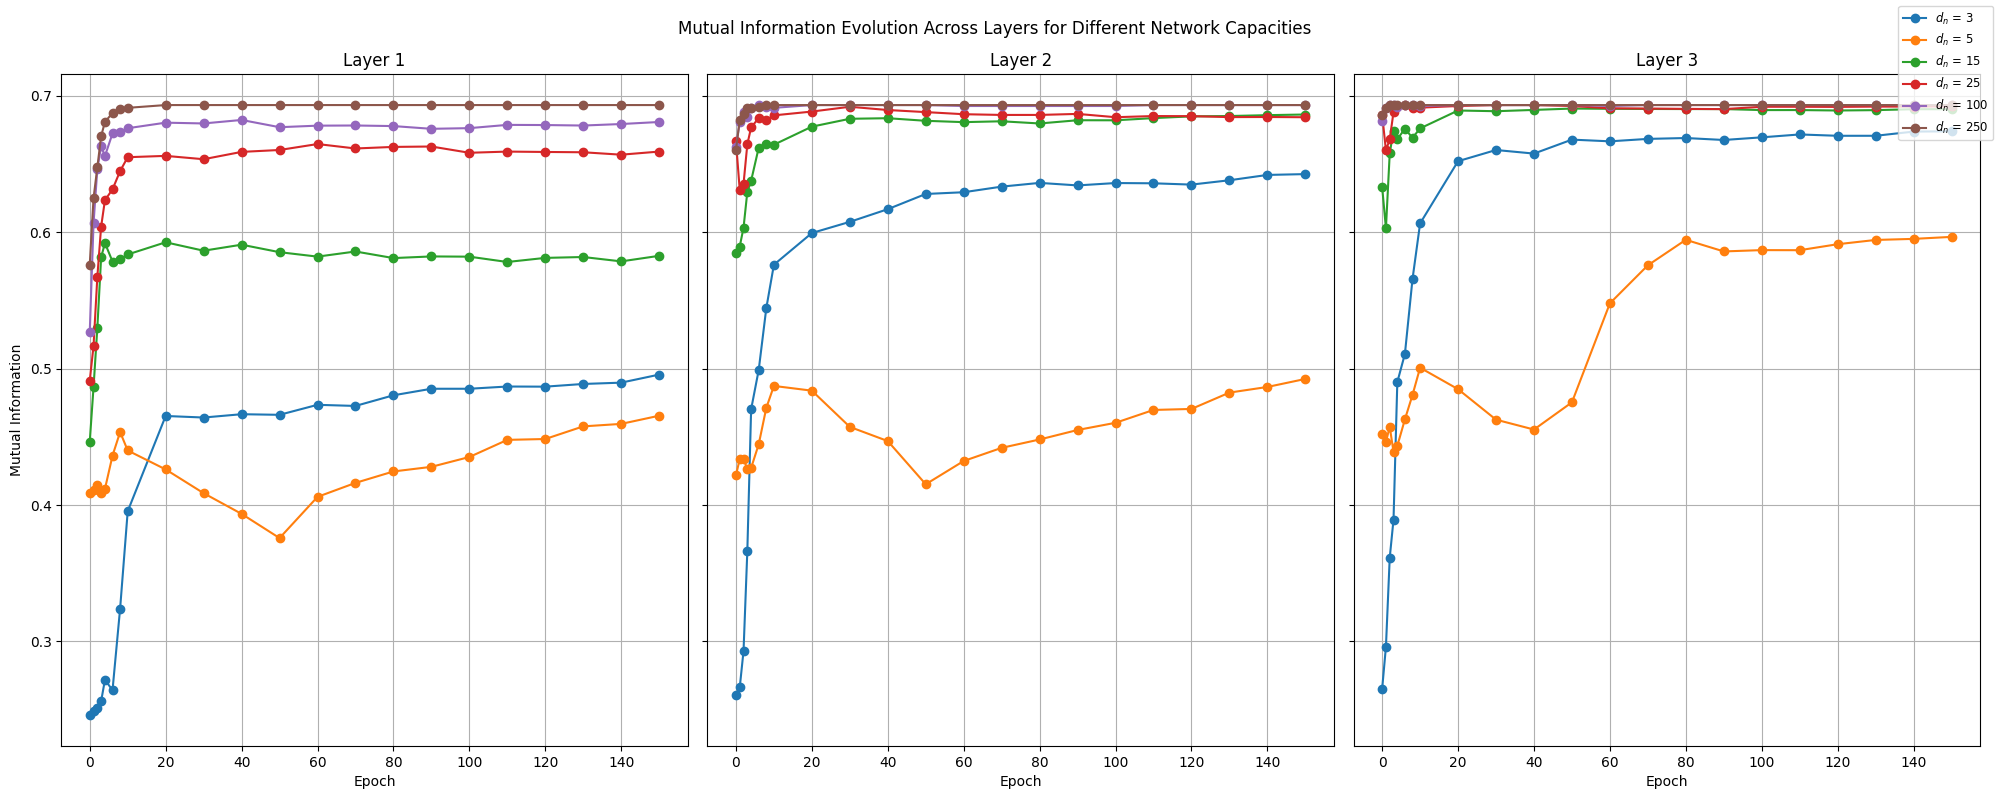

In [ ]:
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(20, 8), sharey=True)
axes[0].set_title("Layer 1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mutual Information")
axes[1].set_title("Layer 2")
axes[1].set_xlabel("Epoch")
axes[2].set_title("Layer 3")
axes[2].set_xlabel("Epoch")
for ax in axes:
    ax.grid(True)
    # ax.axhline(y=H, color='red', linestyle='--')
lines = []
labels = []
# for experiment_key in [3, 5, 7, 9, 11, 15, 20, 25, 50, 75, 100, 150, 250, 500]:
for experiment_key in [3,5,15,25,100,250]:
    line, label = plot_experiment(experiment_key, axes)
    lines.append(line[0])
    labels.append(label)
    
fig.legend(lines, labels, loc='lower right', fontsize='small')
fig.suptitle("Mutual Information Evolution Across Layers for Different Network Capacities")
plt.tight_layout()
plt.show()

In [29]:
fig.show()

/tmp/ipykernel_340467/89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
